In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/jeanmidev/smart-meters-in-london/darksky_parameters_documentation.html
/kaggle/input/datasets/jeanmidev/smart-meters-in-london/weather_hourly_darksky.csv
/kaggle/input/datasets/jeanmidev/smart-meters-in-london/acorn_details.csv
/kaggle/input/datasets/jeanmidev/smart-meters-in-london/uk_bank_holidays.csv
/kaggle/input/datasets/jeanmidev/smart-meters-in-london/weather_daily_darksky.csv
/kaggle/input/datasets/jeanmidev/smart-meters-in-london/daily_dataset.csv
/kaggle/input/datasets/jeanmidev/smart-meters-in-london/informations_households.csv
/kaggle/input/datasets/jeanmidev/smart-meters-in-london/hhblock_dataset/hhblock_dataset/block_97.csv
/kaggle/input/datasets/jeanmidev/smart-meters-in-london/hhblock_dataset/hhblock_dataset/block_27.csv
/kaggle/input/datasets/jeanmidev/smart-meters-in-london/hhblock_dataset/hhblock_dataset/block_55.csv
/kaggle/input/datasets/jeanmidev/smart-meters-in-london/hhblock_dataset/hhblock_dataset/block_0.csv
/kaggle/input/datasets/jeanmi

In [2]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# The hhblock dataset is divided into multiple blocks for scalability, where each block contains a subset of households. 
# Each row represents the daily energy consumption of a household with 48 half-hourly readings.
# Due to the large size of the dataset, initial exploratory analysis is conducted on a representative subset (block_0).

In [4]:
df = pd.read_csv('/kaggle/input/datasets/jeanmidev/smart-meters-in-london/hhblock_dataset/hhblock_dataset/block_0.csv')

In [5]:
# Dataset contains 48 half-hourly readings per day for each household.
# Additional blocks are used later to validate consistency and ensure generalizability.
df.head()

,LCLid,day,hh_0,hh_1,hh_2,hh_3,hh_4,hh_5,hh_6,hh_7,...,hh_38,hh_39,hh_40,hh_41,hh_42,hh_43,hh_44,hh_45,hh_46,hh_47
0,MAC000002,2012-10-13,0.263,0.269,0.275,0.256,0.211,0.136,0.161,0.119,...,0.918,0.278,0.267,0.239,0.230,0.233,0.235,0.188,0.259,0.250
1,MAC000002,2012-10-14,0.262,0.166,0.226,0.088,0.126,0.082,0.123,0.083,...,1.075,0.956,0.821,0.745,0.712,0.511,0.231,0.210,0.278,0.159
2,MAC000002,2012-10-15,0.192,0.097,0.141,0.083,0.132,0.070,0.130,0.074,...,1.164,0.249,0.225,0.258,0.260,0.334,0.299,0.236,0.241,0.237
3,MAC000002,2012-10-16,0.237,0.237,0.193,0.118,0.098,0.107,0.094,0.109,...,0.966,0.172,0.192,0.228,0.203,0.211,0.188,0.213,0.157,0.202
4,MAC000002,2012-10-17,0.157,0.211,0.155,0.169,0.101,0.117,0.084,0.118,...,0.223,0.075,0.230,0.208,0.265,0.377,0.327,0.277,0.288,0.256


In [6]:
df.shape
df.info()  
# hence there are no null entries. However, further validation is required to check for anomalies or outliers.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25286 entries, 0 to 25285
Data columns (total 50 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   LCLid   25286 non-null  object 
 1   day     25286 non-null  object 
 2   hh_0    25286 non-null  float64
 3   hh_1    25286 non-null  float64
 4   hh_2    25286 non-null  float64
 5   hh_3    25286 non-null  float64
 6   hh_4    25286 non-null  float64
 7   hh_5    25286 non-null  float64
 8   hh_6    25286 non-null  float64
 9   hh_7    25286 non-null  float64
 10  hh_8    25286 non-null  float64
 11  hh_9    25286 non-null  float64
 12  hh_10   25286 non-null  float64
 13  hh_11   25286 non-null  float64
 14  hh_12   25286 non-null  float64
 15  hh_13   25286 non-null  float64
 16  hh_14   25286 non-null  float64
 17  hh_15   25286 non-null  float64
 18  hh_16   25286 non-null  float64
 19  hh_17   25286 non-null  float64
 20  hh_18   25286 non-null  float64
 21  hh_19   25286 non-null  float64
 22

In [7]:
# The ‘day’ column is converted to datetime format to enable time-based analysis
df['day'] = pd.to_datetime(df['day'])

In [8]:
# The dataset is sorted by household ID and date to maintain chronological order for time-series modeling.
df = df.sort_values(by=['LCLid', 'day'])

In [9]:
# number of unique households
df['LCLid'].nunique()

50

In [10]:
# The dataset spans from 2011-12-04 to 2014-02-27, capturing long-term consumption patterns.
# covering more than two years of energy consumption data. 
# This allows the model to capture seasonal and long-term consumption patterns.
df['day'].min(), df['day'].max()

(Timestamp('2011-12-04 00:00:00'), Timestamp('2014-02-27 00:00:00'))

In [11]:
df.describe()

,day,hh_0,hh_1,hh_2,hh_3,hh_4,hh_5,hh_6,hh_7,hh_8,...,hh_38,hh_39,hh_40,hh_41,hh_42,hh_43,hh_44,hh_45,hh_46,hh_47
count,25286,25286.000000,25286.000000,25286.000000,25286.000000,25286.000000,25286.000000,25286.000000,25286.000000,25286.000000,...,25286.000000,25286.000000,25286.000000,25286.000000,25286.000000,25286.000000,25286.000000,25286.000000,25286.000000,25286.000000
mean,2013-05-21 05:41:14.127975936,0.352604,0.315774,0.291925,0.276877,0.266721,0.259757,0.254917,0.254986,0.259482,...,0.701088,0.696777,0.697614,0.687187,0.674294,0.640222,0.592294,0.539088,0.468361,0.405305
min,2011-12-04 00:00:00,0.006000,0.007000,0.006000,0.007000,0.007000,0.006000,0.007000,0.007000,0.006000,...,0.007000,0.006000,0.007000,0.007000,0.006000,0.007000,0.007000,0.007000,0.006000,0.007000
25%,2013-01-13 00:00:00,0.113000,0.103000,0.096000,0.093000,0.090000,0.088000,0.087000,0.086000,0.085000,...,0.230000,0.235000,0.242000,0.244000,0.242000,0.240000,0.212000,0.185000,0.152000,0.129000
50%,2013-05-25 00:00:00,0.197000,0.176000,0.163000,0.155000,0.148000,0.145000,0.143000,0.140000,0.139000,...,0.437500,0.436000,0.443000,0.441000,0.441000,0.432000,0.388500,0.357000,0.292000,0.234000
75%,2013-10-06 00:00:00,0.398000,0.353000,0.321000,0.296750,0.282000,0.273000,0.263000,0.258000,0.255000,...,0.946000,0.919000,0.931000,0.900000,0.880000,0.825000,0.764000,0.686000,0.571000,0.470000
max,2014-02-27 00:00:00,6.324000,6.721000,5.614000,5.491000,5.621000,5.461000,5.568000,5.528000,5.547000,...,7.330000,6.759000,5.986000,7.109000,7.359000,7.411000,7.292000,6.386000,6.086000,6.015000
std,NaN,0.424492,0.390572,0.367722,0.353392,0.346461,0.336237,0.334195,0.340934,0.361132,...,0.713959,0.698341,0.687134,0.681529,0.667784,0.620881,0.590376,0.552384,0.512747,0.472222


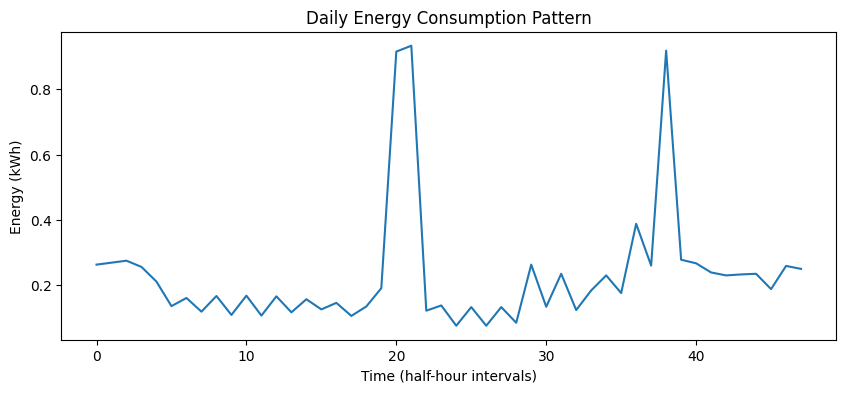

In [12]:
# Daily Energy Pattern of block 0 for energy change over a DAY
# Energy usage of ONE house on ONE day, i.e., first household here
energy_cols = [col for col in df.columns if 'hh_' in col]
sample = df.iloc[0][energy_cols]

plt.figure(figsize=(10,4))
plt.plot(sample.values)
plt.title("Daily Energy Consumption Pattern")
plt.xlabel("Time (half-hour intervals)")
plt.ylabel("Energy (kWh)")
plt.show()

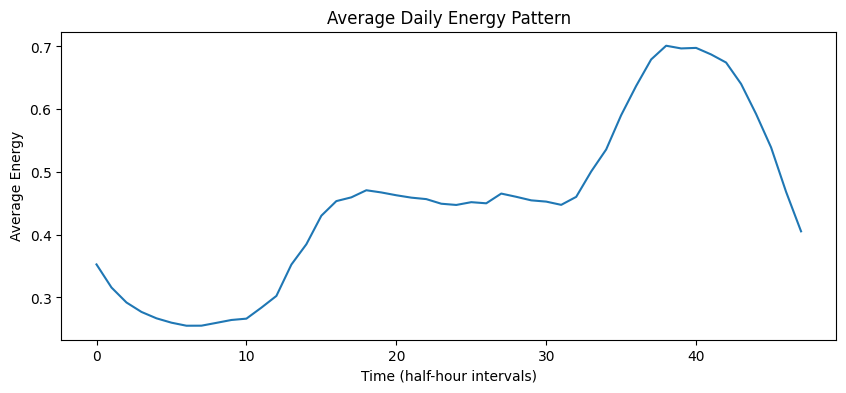

In [13]:
# Average Daily Pattern for common behavior across all users
# The average consumption pattern shows consistent daily trends with peak usage during evening hours, indicating strong temporal dependencies in the data.
avg_day = df[energy_cols].mean()

plt.figure(figsize=(10,4))
plt.plot(avg_day.values)
plt.title("Average Daily Energy Pattern")
plt.xlabel("Time (half-hour intervals)")
plt.ylabel("Average Energy")
plt.show()

Text(0.5, 1.0, 'Outlier Detection')

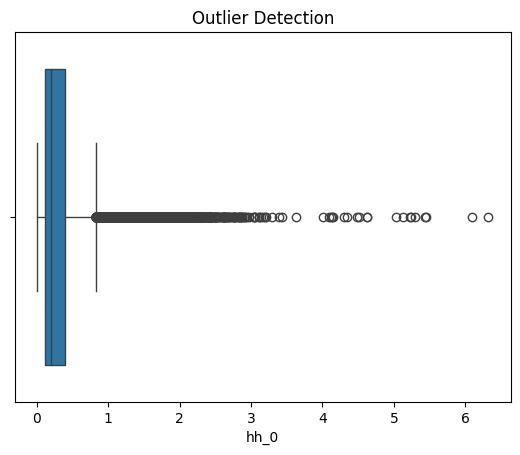

In [17]:
# Outliers are observed in the data
# Representing high energy usage periods rather than noise, and are retained for modeling.
# Energy consumption at midnight (00:00) across all houses and days
sns.boxplot(x=df['hh_0'])
plt.title("Outlier Detection")

Text(0.5, 1.0, 'Overall Energy Distribution')

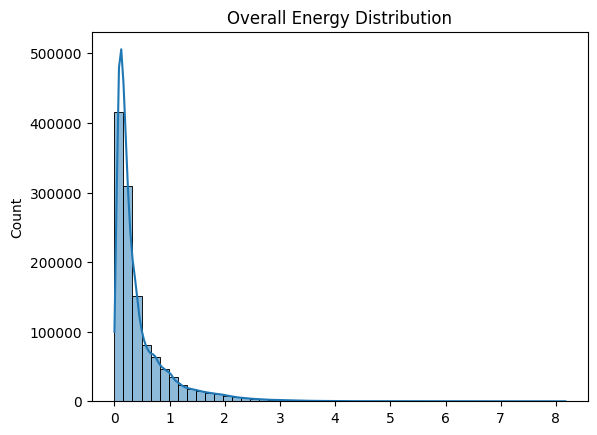

In [18]:
# we are comparing value ranges vs frequency
# Insight  - Data is imbalanced, spikes are imp though
# The distribution is right-skewed, indicating that most energy consumption values are low, with occasional high usage spikes
all_values = df[energy_cols].values.flatten()

sns.histplot(all_values, bins=50, kde=True)
plt.title("Overall Energy Distribution")

Text(0.5, 1.0, 'Energy Distribution at Different Times')

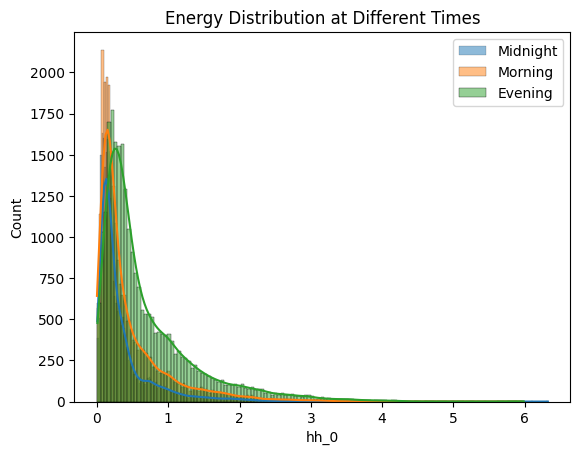

In [19]:
# Energy consumption is not uniform throughout the day
# Analyzing selected time intervals 
sns.histplot(df['hh_0'], label='Midnight', kde=True)
sns.histplot(df['hh_20'], label='Morning', kde=True)
sns.histplot(df['hh_40'], label='Evening', kde=True)

plt.legend()
plt.title("Energy Distribution at Different Times")